# GeoAnnotate — Multi-Class Land Cover Segmentation (Advanced U-Net)

**Goal:** Segment the raster into **4 classes**:

| Index | Class       | Source                                      |
|-------|-------------|---------------------------------------------|
| 0     | other       | `annotations/.../other/*_mask.png`          |
| 1     | crop        | `annotations/.../crops/*_mask.png`          |
| 2     | vegetation  | `annotations/.../vegetation/*_mask.png`     |
| 3     | water       | `annotations/.../water_bodies/*_mask.png`   |

**Architecture:** Pure Advanced U-Net only — **Attention Residual U-Net**.
Residual blocks and attention gates are U-Net enhancements; no ResNet / EfficientNet / Transformer backbones.

**Strategy:**
- Every class (including `other`) is supervised from explicit polygon annotations —
  no random negative patches.
- Extract **rectangular context patches** from the full raster around each annotation.
- **Polygon-only supervision** for classes whose surroundings may share the same class
  (crop, other): the rectangular patch starts as `IGNORE_INDEX` and only the annotated
  polygon(s) contribute to the loss. Water/vegetation use the full rectangle (surroundings
  are genuinely non-class).
- **Heavy per-class augmentation** (flips, rotations, elastic deformation, colour jitter)
  multiplies few-shot classes so vegetation/water are not drowned out by crop.
- **Combined Cross-Entropy + multi-class Dice** loss with inverse-sqrt-frequency class
  weights to handle the residual imbalance.

In [1]:
import json
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset

import rioxarray
import rasterio
from rasterio.transform import rowcol
from scipy.ndimage import binary_erosion, map_coordinates, gaussian_filter

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print('Device:', DEVICE)

Device: cuda


## 1. Configuration

In [2]:
PROJECT_ROOT = Path('..').resolve()

RASTER_NAME = 'T31UCQ_20250919T105629_TCI_10m'
RASTER_PATH = PROJECT_ROOT / 'dataset' / f'{RASTER_NAME}.jp2'
ANNOTATIONS_ROOT = PROJECT_ROOT / 'annotations' / RASTER_NAME

# Class folder -> class index (0 = 'other', also annotated)
CLASS_FOLDERS = {
    'other':        0,
    'crops':        1,
    'vegetation':   2,
    'water_bodies': 3,
}
CLASS_NAMES = ['other', 'crop', 'vegetation', 'water']
NUM_CLASSES = 4

# Classes where the surroundings of an annotation are NOT reliably non-class
# (neighbouring crop fields; other annotation polygons that happen to sit next
# to another annotated region). For these, only the annotated polygon and any
# overlapping annotations are supervised; the rest of the rectangular patch is
# ignored. Water and vegetation keep their full rectangle as 'other'.
POLYGON_ONLY_CLASSES = {0, 1}

# Colour palette for visualisation (RGB 0-1)
CLASS_COLORS = np.array([
    [0.15, 0.15, 0.15],  # other   - dark grey
    [1.00, 0.80, 0.10],  # crop    - yellow
    [0.20, 0.75, 0.20],  # veg     - green
    [0.10, 0.45, 0.95],  # water   - blue
])

PATCH_SIZE       = 128
BATCH_SIZE       = 8
EPOCHS           = 100
LEARNING_RATE    = 1e-4
WEIGHT_DECAY     = 1e-4
VAL_SPLIT        = 0.2

# Per-class augmentation multiplier: few-shot classes get multiplied more.
# 'other' is included too so the model sees plenty of explicit non-class supervision.
AUG_MULT_PER_CLASS = {0: 8, 1: 4, 2: 16, 3: 16}
MASK_ERODE_PIXELS  = 1

# Target value for pixels that should not contribute to the loss.
IGNORE_INDEX = 255

MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)
BEST_MODEL = MODELS_DIR / 'advanced_unet_multiclass.pt'

for cls_name in CLASS_FOLDERS:
    folder = ANNOTATIONS_ROOT / cls_name
    n = len(list(folder.glob('*_meta.json'))) if folder.exists() else 0
    print(f'{cls_name:15s}: {n} annotations')


other          : 13 annotations
crops          : 66 annotations
vegetation     : 19 annotations
water_bodies   : 14 annotations


## 2. Load Full Raster (EPSG:3857)

The annotation PNGs were rendered from this raster after it was reprojected to EPSG:3857
(see `backend/tile_renderer.py`). We reproject here too so **negative patches** sampled from
the raster share the same pixel scale and colour profile as the positive annotation PNGs.
The raster is also used at the end for full-scene inference.

Loading raster: /home/geoknight/Desktop/Learning/Personal Project/GeoAnnotate/dataset/T31UCQ_20250919T105629_TCI_10m.jp2
Native shape: (3, 10980, 10980) | native CRS: EPSG:32631
Reprojected shape: (3, 11281, 11250) | CRS: EPSG:3857
Raster ready: (3, 11281, 11250) min/max: 0.0 0.99607843


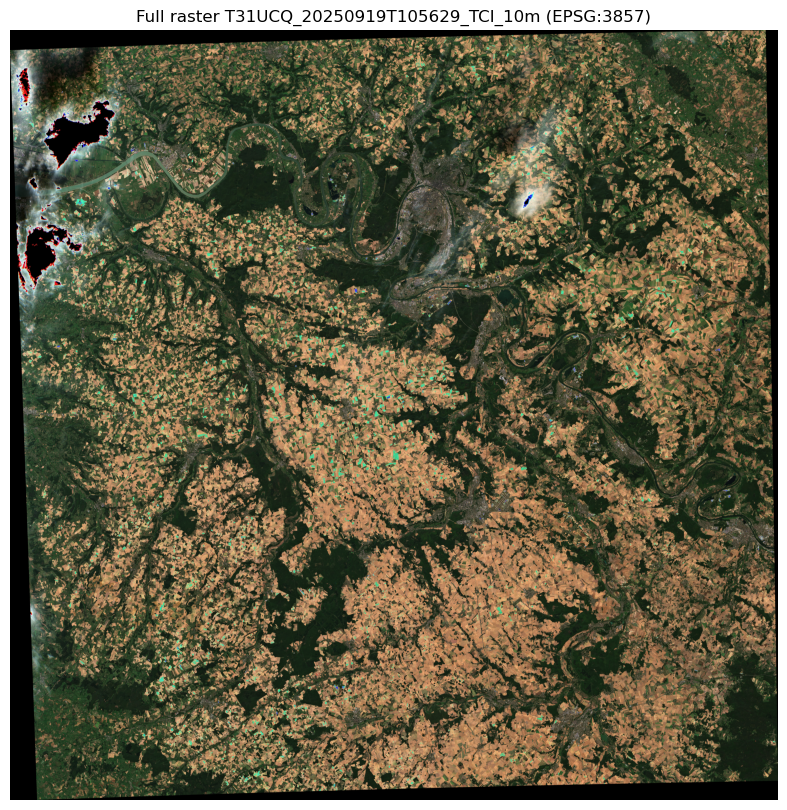

In [3]:
print('Loading raster:', RASTER_PATH)
da_native = rioxarray.open_rasterio(RASTER_PATH)
print('Native shape:', da_native.shape, '| native CRS:', da_native.rio.crs)

da = da_native.rio.reproject('EPSG:3857')
print('Reprojected shape:', da.shape, '| CRS:', da.rio.crs)

full_raster = da.values.astype(np.float32)         # (3, H, W)
if da.rio.nodata is not None:
    full_raster = np.where(full_raster == da.rio.nodata, 0, full_raster)
if full_raster.max() > 1.5:
    full_raster = full_raster / 255.0
full_raster = np.clip(full_raster, 0.0, 1.0)

RASTER_C, RASTER_H, RASTER_W = full_raster.shape
raster_transform = da.rio.transform()
print('Raster ready:', full_raster.shape, 'min/max:', full_raster.min(), full_raster.max())

plt.figure(figsize=(10, 10))
plt.imshow(full_raster.transpose(1, 2, 0))
plt.title(f'Full raster {RASTER_NAME} (EPSG:3857)')
plt.axis('off'); plt.show()

## 3. Collect Annotation Metadata (bounds + mask)

For each `_meta.json` across all 3 class folders we convert the geographic bounds into
raster-pixel coordinates, resize the class mask to fit that pixel box, optionally erode
noisy edges, and remember the class index.

During training we will extract **rectangular patches from the full raster** centred on
each annotation — this gives the model real satellite context around the labelled region
(no transparent borders) and allows multiple overlapping annotations to be painted into
the same patch with their respective class indices.

In [4]:
raster_bounds = da.rio.bounds()  # (left, bottom, right, top)

annotation_patches = []
skip_reasons = {'missing_mask': 0, 'out_of_bounds': 0, 'too_small': 0, 'empty_mask': 0}

for cls_folder, cls_idx in CLASS_FOLDERS.items():
    folder = ANNOTATIONS_ROOT / cls_folder
    if not folder.exists():
        print(f'Missing folder: {folder}'); continue
    for meta_path in sorted(folder.glob('*_meta.json')):
        meta = json.loads(meta_path.read_text())
        mask_path = meta_path.with_name(meta_path.stem.replace('_meta', '') + '_mask.png')
        if not mask_path.exists():
            skip_reasons['missing_mask'] += 1; continue

        minx, miny, maxx, maxy = meta['bounds']
        if maxx < raster_bounds[0] or minx > raster_bounds[2] or \
           maxy < raster_bounds[1] or miny > raster_bounds[3]:
            skip_reasons['out_of_bounds'] += 1; continue

        row_top, col_left  = rowcol(raster_transform, minx, maxy)
        row_bot, col_right = rowcol(raster_transform, maxx, miny)
        r0, r1 = sorted([row_top, row_bot])
        c0, c1 = sorted([col_left, col_right])
        r0 = max(0, r0); c0 = max(0, c0)
        r1 = min(RASTER_H, r1); c1 = min(RASTER_W, c1)
        h_px, w_px = r1 - r0, c1 - c0
        if h_px < 8 or w_px < 8:
            skip_reasons['too_small'] += 1; continue

        mask_img = Image.open(mask_path).convert('L').resize((w_px, h_px), Image.NEAREST)
        mask_bin = (np.array(mask_img) > 127)
        if MASK_ERODE_PIXELS > 0 and mask_bin.sum() > 50:
            mask_bin = binary_erosion(mask_bin, iterations=MASK_ERODE_PIXELS)
        if mask_bin.sum() < 20:
            skip_reasons['empty_mask'] += 1; continue

        cy = (r0 + r1) // 2
        cx = (c0 + c1) // 2
        annotation_patches.append({
            'id':        meta['id'],
            'class_idx': cls_idx,
            'class':     CLASS_NAMES[cls_idx],
            'r0': r0, 'r1': r1, 'c0': c0, 'c1': c1,
            'cy': cy, 'cx': cx,
            'mask':      mask_bin.astype(np.uint8),
        })

print(f'Loaded {len(annotation_patches)} annotations')
print('Skip reasons:', skip_reasons)
for idx in range(NUM_CLASSES):
    n = sum(1 for a in annotation_patches if a['class_idx'] == idx)
    print(f'  {CLASS_NAMES[idx]:12s}: {n}')

Loaded 112 annotations
Skip reasons: {'missing_mask': 0, 'out_of_bounds': 0, 'too_small': 0, 'empty_mask': 0}
  other       : 13
  crop        : 66
  vegetation  : 19
  water       : 14


## 4. Dataset — Positive-only (all classes anchor their own patches)

Every annotated class — including `other` — supplies anchor patches via `PositivePatchDataset`.
There are no random "negative" patches: the model learns class `other` from explicit `other`
annotations.

- **Crop / other anchors** → polygon-only: start mask as `IGNORE_INDEX`, only the annotated
  polygon and any overlapping annotations are supervised. Prevents contradictory "this looks
  like X but is labelled Y" signals when crop fields (or the terrain near an *other*
  annotation) blend into their neighbours.
- **Water / vegetation anchors** → full rectangle: surroundings start as `0` (other) because
  the area around a lake or forest is genuinely non-class → clean negatives.

In [5]:
def elastic_deform(img, mask, alpha=80, sigma=10, rng=None):
    """img (C,H,W) float, mask (H,W) int — returns deformed versions."""
    rng = rng or np.random
    _, h, w = img.shape
    dx = gaussian_filter((rng.rand(h, w) * 2 - 1), sigma) * alpha
    dy = gaussian_filter((rng.rand(h, w) * 2 - 1), sigma) * alpha
    yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    coords = np.stack([yy + dy, xx + dx])
    img_out  = np.stack([map_coordinates(img[c], coords, order=1, mode='reflect') for c in range(img.shape[0])])
    mask_out = map_coordinates(mask, coords, order=0, mode='reflect')
    return img_out.astype(np.float32), mask_out.astype(np.int64)

def random_augment(img, mask, rng):
    if rng.rand() < 0.5:
        img = img[:, :, ::-1].copy(); mask = mask[:, ::-1].copy()
    if rng.rand() < 0.5:
        img = img[:, ::-1, :].copy(); mask = mask[::-1, :].copy()
    k = rng.randint(0, 4)
    if k:
        img = np.rot90(img, k, axes=(1, 2)).copy(); mask = np.rot90(mask, k).copy()
    if rng.rand() < 0.3:
        img, mask = elastic_deform(img, mask, alpha=60, sigma=9, rng=rng)
    if rng.rand() < 0.5:
        img = np.clip(img * rng.uniform(0.85, 1.15), 0, 1)
    if rng.rand() < 0.5:
        mean = img.mean(axis=(1, 2), keepdims=True)
        img = np.clip((img - mean) * rng.uniform(0.85, 1.15) + mean, 0, 1)
    return img.astype(np.float32), mask.astype(np.int64)

In [6]:
class PositivePatchDataset(Dataset):
    """Rectangular patches from the full raster centred on each annotation.

    If the anchor annotation's class is in POLYGON_ONLY_CLASSES, the patch starts
    as IGNORE_INDEX everywhere and only the anchor polygon + any overlapping
    annotations get painted in. Otherwise the patch starts as 0 ('other') and
    the surroundings provide a clean negative signal.
    """
    def __init__(self, full_raster, annotations, all_annotations, patch_size,
                 aug_mult_per_class, augment=True, seed=0):
        self.full = full_raster
        self.ann  = annotations            # drives sampling (train or val)
        self.all  = all_annotations        # every annotation, for overlap-painting
        self.ps   = patch_size
        self.aug  = augment
        self.seed = seed
        self.index = []
        for i, a in enumerate(annotations):
            mult = aug_mult_per_class.get(a['class_idx'], 1) if augment else 1
            self.index.extend([i] * mult)

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        rng = np.random.RandomState(self.seed + idx * 31)
        ann = self.ann[self.index[idx]]
        ps  = self.ps
        cy, cx = ann['cy'], ann['cx']

        if self.aug:
            jit = ps // 5
            cy += rng.randint(-jit, jit + 1)
            cx += rng.randint(-jit, jit + 1)

        y0 = int(np.clip(cy - ps // 2, 0, RASTER_H - ps))
        x0 = int(np.clip(cx - ps // 2, 0, RASTER_W - ps))
        y1, x1 = y0 + ps, x0 + ps

        img_patch = self.full[:, y0:y1, x0:x1].copy()

        if ann['class_idx'] in POLYGON_ONLY_CLASSES:
            mask_patch = np.full((ps, ps), IGNORE_INDEX, dtype=np.int64)
        else:
            mask_patch = np.zeros((ps, ps), dtype=np.int64)

        for other in self.all:
            if other['r1'] <= y0 or other['r0'] >= y1: continue
            if other['c1'] <= x0 or other['c0'] >= x1: continue
            ov_r0, ov_r1 = max(other['r0'], y0), min(other['r1'], y1)
            ov_c0, ov_c1 = max(other['c0'], x0), min(other['c1'], x1)
            m = other['mask'][ov_r0 - other['r0']:ov_r1 - other['r0'],
                              ov_c0 - other['c0']:ov_c1 - other['c0']]
            tgt = mask_patch[ov_r0 - y0:ov_r1 - y0, ov_c0 - x0:ov_c1 - x0]
            tgt[m > 0] = other['class_idx']

        if self.aug:
            img_patch, mask_patch = random_augment(img_patch, mask_patch, rng)

        return torch.from_numpy(img_patch).float(), torch.from_numpy(mask_patch).long()

In [7]:
# Stratified split: keep class ratios in train & val (includes class 0 = 'other')
rng = np.random.RandomState(SEED)
train_ann, val_ann = [], []
for cls_idx in CLASS_FOLDERS.values():
    subset = [a for a in annotation_patches if a['class_idx'] == cls_idx]
    rng.shuffle(subset)
    n_val = max(1, int(round(len(subset) * VAL_SPLIT))) if subset else 0
    val_ann.extend(subset[:n_val])
    train_ann.extend(subset[n_val:])
rng.shuffle(train_ann); rng.shuffle(val_ann)

print(f'Train annotations: {len(train_ann)} | Val annotations: {len(val_ann)}')
for cls_idx in range(NUM_CLASSES):
    nt = sum(1 for a in train_ann if a['class_idx'] == cls_idx)
    nv = sum(1 for a in val_ann   if a['class_idx'] == cls_idx)
    print(f'  {CLASS_NAMES[cls_idx]:12s} train={nt:3d}  val={nv:3d}')

train_ds = PositivePatchDataset(full_raster, train_ann, annotation_patches, PATCH_SIZE,
                                AUG_MULT_PER_CLASS, augment=True,  seed=101)
val_ds   = PositivePatchDataset(full_raster, val_ann,   annotation_patches, PATCH_SIZE,
                                AUG_MULT_PER_CLASS, augment=False, seed=303)
print(f'Train samples: {len(train_ds)} | Val samples: {len(val_ds)}')

Train annotations: 89 | Val annotations: 23
  other        train= 10  val=  3
  crop         train= 53  val= 13
  vegetation   train= 15  val=  4
  water        train= 11  val=  3
Train samples: 708 | Val samples: 23


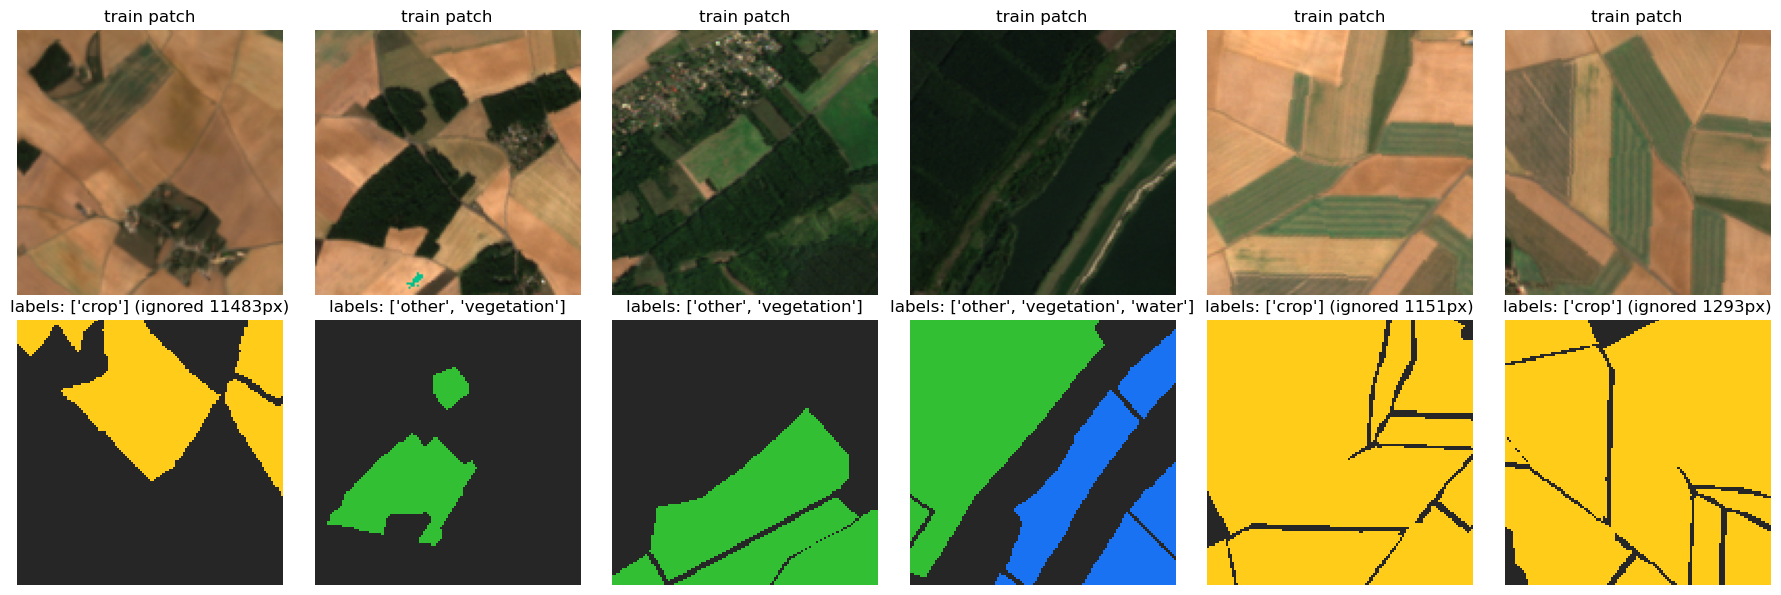

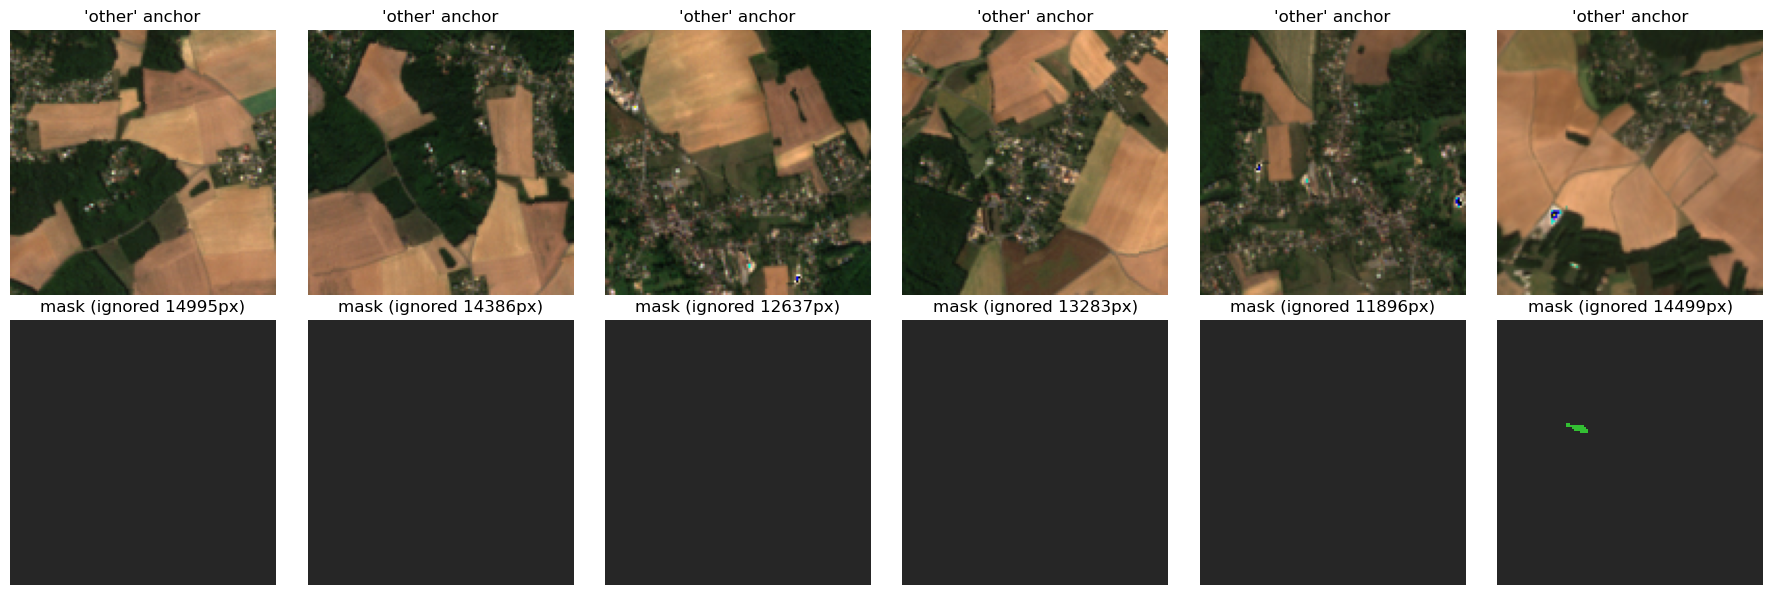

In [8]:
cmap = mcolors.ListedColormap(CLASS_COLORS)
norm = mcolors.BoundaryNorm(np.arange(NUM_CLASSES + 1) - 0.5, NUM_CLASSES)

def mask_for_display(m):
    """IGNORE_INDEX pixels are shown as 'other' colour in visualisations only."""
    disp = m.copy()
    disp[disp == IGNORE_INDEX] = 0
    return disp

# Indices of class-0 ('other') anchors in the *training* dataset, if any
other_train_idx = [i for i, a in enumerate(train_ann) if a['class_idx'] == 0]

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col in range(6):
    img, mask = train_ds[col * max(1, len(train_ds) // 6)]
    axes[0, col].imshow(img.numpy().transpose(1, 2, 0))
    axes[0, col].set_title('train patch'); axes[0, col].axis('off')
    axes[1, col].imshow(mask_for_display(mask.numpy()), cmap=cmap, norm=norm, interpolation='nearest')
    classes_here = [c for c in np.unique(mask.numpy()) if c != IGNORE_INDEX]
    ignored = int((mask.numpy() == IGNORE_INDEX).sum())
    title = f'labels: {[CLASS_NAMES[c] for c in classes_here]}'
    if ignored:
        title += f' (ignored {ignored}px)'
    axes[1, col].set_title(title); axes[1, col].axis('off')
plt.tight_layout(); plt.show()

# Show class-0 ('other') anchors specifically, if the annotated other/ folder supplied any
if other_train_idx:
    picks = [train_ds.index.index(i) for i in other_train_idx[:6] if i in train_ds.index][:6]
    if picks:
        fig, axes = plt.subplots(2, len(picks), figsize=(3 * len(picks), 6), squeeze=False)
        for col, ds_idx in enumerate(picks):
            img, mask = train_ds[ds_idx]
            axes[0, col].imshow(img.numpy().transpose(1, 2, 0))
            axes[0, col].set_title("'other' anchor"); axes[0, col].axis('off')
            axes[1, col].imshow(mask_for_display(mask.numpy()), cmap=cmap, norm=norm, interpolation='nearest')
            ignored = int((mask.numpy() == IGNORE_INDEX).sum())
            axes[1, col].set_title(f'mask (ignored {ignored}px)'); axes[1, col].axis('off')
        plt.tight_layout(); plt.show()
else:
    print("No 'other' anchors found in training set — check annotations/.../other/")

## 5. Advanced U-Net — Attention Residual U-Net

Pure U-Net family. The enhancements are standard U-Net improvements:

1. **Residual double-conv** blocks inside each encoder/decoder level (stabilise deep training).
2. **Attention gates** on skip connections (suppress irrelevant features from the encoder).
3. **Classical symmetric U-Net depth of 5 levels**, channels 64 → 128 → 256 → 512 → 1024.
4. **Transposed-convolution upsampling** in the decoder.
5. **4-channel output** for multi-class segmentation.

In [9]:
class ResidualDoubleConv(nn.Module):
    """Two 3x3 Conv-BN-ReLU with a residual skip (1x1 projection if channels differ)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.proj  = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = self.proj(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)


class AttentionGate(nn.Module):
    """Additive attention gate (Oktay et al. 2018). Gates the encoder skip with the decoder feature."""
    def __init__(self, gate_ch, skip_ch, inter_ch):
        super().__init__()
        self.Wg = nn.Sequential(nn.Conv2d(gate_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
        self.Wx = nn.Sequential(nn.Conv2d(skip_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
        self.psi = nn.Sequential(nn.Conv2d(inter_ch, 1, 1, bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        a = self.relu(self.Wg(g) + self.Wx(x))
        return x * self.psi(a)


class UpBlock(nn.Module):
    """Upsample + attention-gated skip + residual double conv."""
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.att  = AttentionGate(gate_ch=out_ch, skip_ch=skip_ch, inter_ch=out_ch // 2 or 1)
        self.conv = ResidualDoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # Pad if needed (odd dimensions)
        dy = skip.size(2) - x.size(2)
        dx = skip.size(3) - x.size(3)
        if dy or dx:
            x = F.pad(x, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        skip = self.att(g=x, x=skip)
        return self.conv(torch.cat([x, skip], dim=1))


class AttentionResUNet(nn.Module):
    """Advanced U-Net: 5-level symmetric encoder/decoder with residual blocks + attention gates."""
    def __init__(self, in_ch=3, num_classes=NUM_CLASSES, base=64):
        super().__init__()
        c1, c2, c3, c4, c5 = base, base * 2, base * 4, base * 8, base * 16
        self.enc1 = ResidualDoubleConv(in_ch, c1)
        self.enc2 = ResidualDoubleConv(c1, c2)
        self.enc3 = ResidualDoubleConv(c2, c3)
        self.enc4 = ResidualDoubleConv(c3, c4)
        self.bott = ResidualDoubleConv(c4, c5)
        self.pool = nn.MaxPool2d(2)
        self.up4  = UpBlock(c5, c4, c4)
        self.up3  = UpBlock(c4, c3, c3)
        self.up2  = UpBlock(c3, c2, c2)
        self.up1  = UpBlock(c2, c1, c1)
        self.head = nn.Conv2d(c1, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bott(self.pool(e4))
        d4 = self.up4(b,  e4)
        d3 = self.up3(d4, e3)
        d2 = self.up2(d3, e2)
        d1 = self.up1(d2, e1)
        return self.head(d1)

model = AttentionResUNet().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'AttentionResUNet parameters: {n_params:,}')
with torch.no_grad():
    dummy = torch.randn(2, 3, PATCH_SIZE, PATCH_SIZE).to(DEVICE)
    print('Output shape:', model(dummy).shape)

AttentionResUNet parameters: 32,781,228
Output shape: torch.Size([2, 4, 128, 128])


## 6. Multi-Class Loss — Cross-Entropy + Dice

Weighted cross-entropy handles per-pixel classification; multi-class Dice optimises
region overlap and compensates for class imbalance.

In [10]:
class MultiClassDiceLoss(nn.Module):
    """Dice over foreground classes; ignores pixels where target == ignore_index."""
    def __init__(self, num_classes, ignore_index=IGNORE_INDEX, smooth=1.0, ignore_bg=True):
        super().__init__()
        self.nc = num_classes; self.smooth = smooth
        self.ignore_index = ignore_index; self.ignore_bg = ignore_bg

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)                             # (B,C,H,W)
        valid = (targets != self.ignore_index).float().unsqueeze(1)  # (B,1,H,W)
        safe  = torch.where(targets == self.ignore_index,
                            torch.zeros_like(targets), targets)
        onehot = F.one_hot(safe, self.nc).permute(0, 3, 1, 2).float() * valid
        probs  = probs * valid
        start  = 1 if self.ignore_bg else 0
        dims   = (0, 2, 3)
        inter  = (probs[:, start:] * onehot[:, start:]).sum(dims)
        denom  = probs[:, start:].sum(dims) + onehot[:, start:].sum(dims)
        dice   = (2 * inter + self.smooth) / (denom + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    def __init__(self, class_weights, num_classes, ignore_index=IGNORE_INDEX):
        super().__init__()
        self.ce   = nn.CrossEntropyLoss(weight=class_weights, ignore_index=ignore_index)
        self.dice = MultiClassDiceLoss(num_classes, ignore_index=ignore_index)

    def forward(self, logits, targets):
        return self.ce(logits, targets) + self.dice(logits, targets)

# Class weights: inverse-sqrt frequency, excluding IGNORE_INDEX
pixel_counts = np.zeros(NUM_CLASSES, dtype=np.float64)
sample_n = min(200, len(train_ds))
for i in np.linspace(0, len(train_ds) - 1, sample_n, dtype=int):
    _, m = train_ds[i]
    m = m.numpy()
    m = m[m != IGNORE_INDEX]
    vals, cnts = np.unique(m, return_counts=True)
    for v, c in zip(vals, cnts):
        pixel_counts[int(v)] += c
freq = pixel_counts / max(1, pixel_counts.sum())
weights = 1.0 / np.sqrt(freq + 1e-6)
weights = weights / weights.mean()
print('Pixel distribution:', dict(zip(CLASS_NAMES, (freq * 100).round(2))))
print('CE class weights  :', dict(zip(CLASS_NAMES, weights.round(3))))
class_weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

Pixel distribution: {'other': np.float64(53.23), 'crop': np.float64(21.79), 'vegetation': np.float64(16.16), 'water': np.float64(8.83)}
CE class weights  : {'other': np.float64(0.585), 'crop': np.float64(0.915), 'vegetation': np.float64(1.062), 'water': np.float64(1.437)}


## 7. Training

In [ ]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
criterion = CombinedLoss(class_weights=class_weights, num_classes=NUM_CLASSES)

def mean_dice(logits, targets, num_classes, ignore_bg=True):
    preds = logits.argmax(1)
    valid = targets != IGNORE_INDEX
    dices = []
    start = 1 if ignore_bg else 0
    for c in range(start, num_classes):
        p = (preds == c) & valid
        t = (targets == c) & valid
        inter = (p & t).sum().float(); denom = p.sum().float() + t.sum().float()
        if denom > 0:
            dices.append(((2 * inter + 1) / (denom + 1)).item())
    return float(np.mean(dices)) if dices else 0.0

history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'lr': []}
best_val = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train(); tl = 0.0; n = 0
    for img, mask in train_loader:
        img, mask = img.to(DEVICE), mask.to(DEVICE)
        optimizer.zero_grad()
        logits = model(img)
        loss   = criterion(logits, mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tl += loss.item() * img.size(0); n += img.size(0)
    train_loss = tl / max(1, n)

    model.eval(); vl = 0.0; vd = 0.0; nv = 0
    with torch.no_grad():
        for img, mask in val_loader:
            img, mask = img.to(DEVICE), mask.to(DEVICE)
            logits = model(img)
            vl += criterion(logits, mask).item() * img.size(0)
            vd += mean_dice(logits, mask, NUM_CLASSES) * img.size(0)
            nv += img.size(0)
    val_loss = vl / max(1, nv); val_dice = vd / max(1, nv)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    scheduler.step()

    if val_dice > best_val:
        best_val = val_dice
        torch.save(model.state_dict(), BEST_MODEL)
        flag = ' *'
    else:
        flag = ''

    print(f'Epoch {epoch:3d}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_dice={val_dice:.4f}{flag}')

print(f'\nBest val Dice: {best_val:.4f} -> {BEST_MODEL}')

Epoch   1/100  train_loss=1.4693  val_loss=0.9436  val_dice=0.7383 *
Epoch   2/100  train_loss=0.9822  val_loss=0.6705  val_dice=0.8580 *


## 8. Training Curves

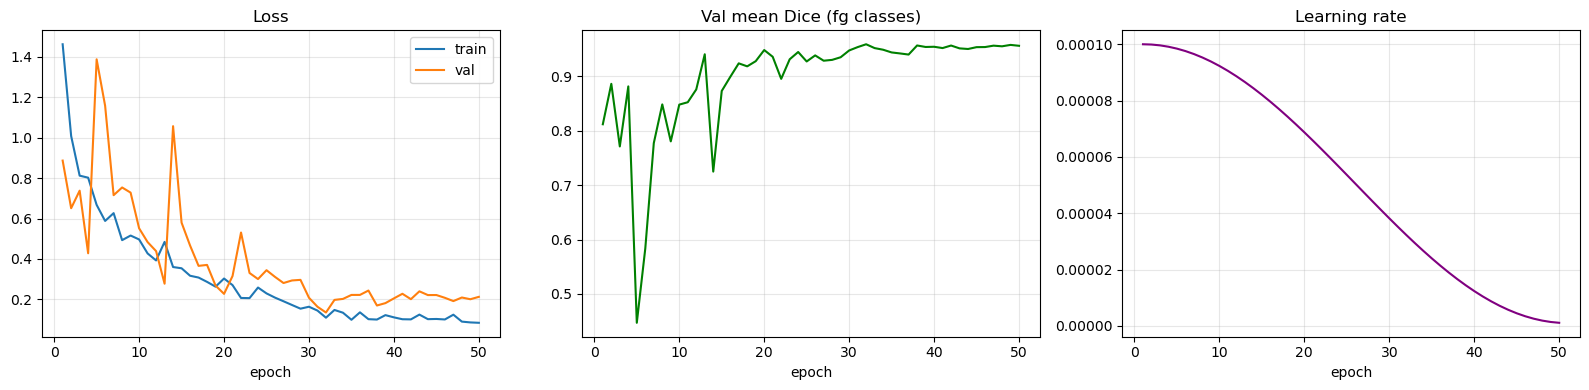

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ep = range(1, len(history['train_loss']) + 1)
axes[0].plot(ep, history['train_loss'], label='train'); axes[0].plot(ep, history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, history['val_dice'], color='green'); axes[1].set_title('Val mean Dice (fg classes)')
axes[1].set_xlabel('epoch'); axes[1].grid(alpha=0.3)
axes[2].plot(ep, history['lr'], color='purple'); axes[2].set_title('Learning rate'); axes[2].set_xlabel('epoch')
axes[2].grid(alpha=0.3); plt.tight_layout(); plt.show()

## 9. Visual Evaluation on Validation Samples

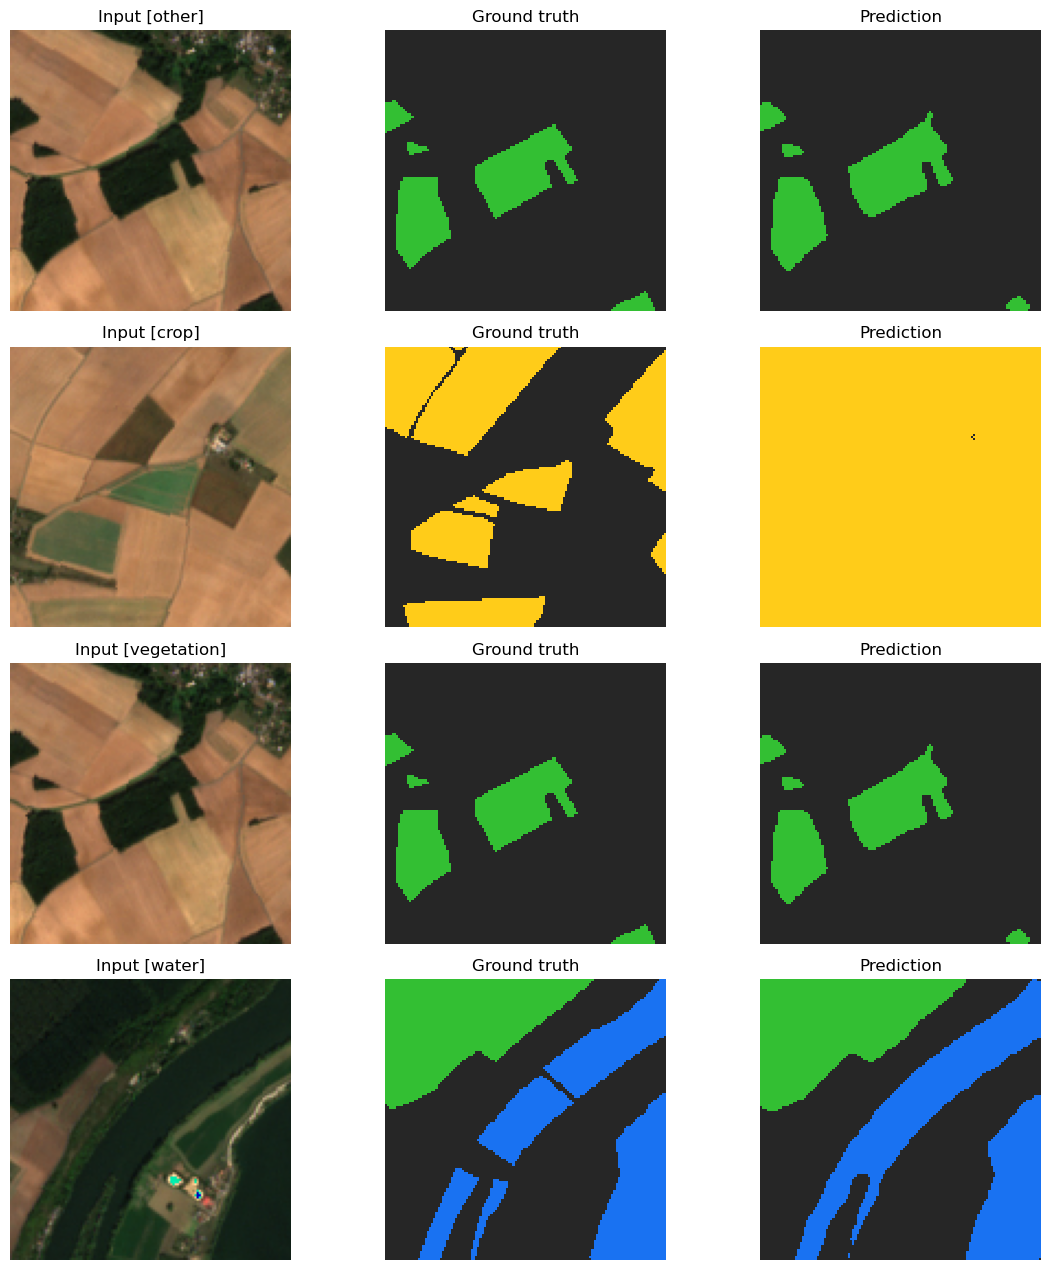

In [13]:
model.load_state_dict(torch.load(BEST_MODEL, map_location=DEVICE))
model.eval()

def pick_sample_per_class():
    """Find one val_ds index whose mask contains >50 pixels of each class."""
    picks = {}
    for i in range(len(val_ds)):
        _, m = val_ds[i]
        m_np = m.numpy()
        for c in range(NUM_CLASSES):
            if c not in picks and (m_np == c).sum() > 50:
                picks[c] = i
        if len(picks) == NUM_CLASSES:
            break
    return picks

picks = pick_sample_per_class()

fig, axes = plt.subplots(len(picks), 3, figsize=(12, 3.2 * len(picks)))
if len(picks) == 1:
    axes = axes[None, :]
for row, c in enumerate(sorted(picks.keys())):
    img, mask = val_ds[picks[c]]
    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(DEVICE))
        pred   = logits.argmax(1).squeeze(0).cpu().numpy()
    axes[row, 0].imshow(img.numpy().transpose(1, 2, 0))
    axes[row, 0].set_title(f'Input [{CLASS_NAMES[c]}]'); axes[row, 0].axis('off')
    axes[row, 1].imshow(mask_for_display(mask.numpy()), cmap=cmap, norm=norm, interpolation='nearest')
    axes[row, 1].set_title('Ground truth'); axes[row, 1].axis('off')
    axes[row, 2].imshow(pred, cmap=cmap, norm=norm, interpolation='nearest')
    axes[row, 2].set_title('Prediction'); axes[row, 2].axis('off')
plt.tight_layout(); plt.show()

## 10. Per-Class Metrics on Validation Set

In [14]:
model.eval()
tp = np.zeros(NUM_CLASSES, dtype=np.int64)
fp = np.zeros(NUM_CLASSES, dtype=np.int64)
fn = np.zeros(NUM_CLASSES, dtype=np.int64)

with torch.no_grad():
    for img, mask in val_loader:
        img = img.to(DEVICE); mask_np = mask.numpy()
        pred = model(img).argmax(1).cpu().numpy()
        valid = mask_np != IGNORE_INDEX
        for c in range(NUM_CLASSES):
            p = (pred == c) & valid; t = (mask_np == c) & valid
            tp[c] += int(( p &  t).sum())
            fp[c] += int(( p & ~t).sum())
            fn[c] += int((~p &  t).sum())

print(f'{"class":12s} {"dice":>8s} {"iou":>8s} {"precision":>10s} {"recall":>8s}')
for c in range(NUM_CLASSES):
    dice = (2 * tp[c]) / max(1, 2 * tp[c] + fp[c] + fn[c])
    iou  = tp[c] / max(1, tp[c] + fp[c] + fn[c])
    prec = tp[c] / max(1, tp[c] + fp[c])
    rec  = tp[c] / max(1, tp[c] + fn[c])
    print(f'{CLASS_NAMES[c]:12s} {dice:8.4f} {iou:8.4f} {prec:10.4f} {rec:8.4f}')

class            dice      iou  precision   recall
other          0.9589   0.9210     0.9620   0.9558
crop           1.0000   0.9999     1.0000   0.9999
vegetation     0.9283   0.8662     0.9336   0.9231
water          0.9162   0.8453     0.8844   0.9503


## 11. Full-Raster Inference (Sliding-Window)

In [15]:
stride  = PATCH_SIZE // 2
logits_sum = np.zeros((NUM_CLASSES, RASTER_H, RASTER_W), dtype=np.float32)
counts     = np.zeros((RASTER_H, RASTER_W), dtype=np.float32)

model.eval()
with torch.no_grad():
    ys = list(range(0, RASTER_H - PATCH_SIZE + 1, stride)) + [RASTER_H - PATCH_SIZE]
    xs = list(range(0, RASTER_W - PATCH_SIZE + 1, stride)) + [RASTER_W - PATCH_SIZE]
    ys = sorted(set(ys)); xs = sorted(set(xs))
    total = len(ys) * len(xs); done = 0
    for y in ys:
        for x in xs:
            patch = full_raster[:, y:y + PATCH_SIZE, x:x + PATCH_SIZE]
            t = torch.from_numpy(patch).float().unsqueeze(0).to(DEVICE)
            probs = F.softmax(model(t), dim=1).squeeze(0).cpu().numpy()
            logits_sum[:, y:y + PATCH_SIZE, x:x + PATCH_SIZE] += probs
            counts[y:y + PATCH_SIZE, x:x + PATCH_SIZE] += 1
            done += 1
            if done % 200 == 0 or done == total:
                print(f'  tile {done}/{total}')

avg_probs   = logits_sum / np.maximum(counts[None, ...], 1)
pred_classes = avg_probs.argmax(0).astype(np.uint8)
print('Full prediction shape:', pred_classes.shape)
print('Class pixel counts:', {CLASS_NAMES[c]: int((pred_classes == c).sum()) for c in range(NUM_CLASSES)})

  tile 200/30800
  tile 400/30800
  tile 600/30800
  tile 800/30800
  tile 1000/30800
  tile 1200/30800
  tile 1400/30800
  tile 1600/30800
  tile 1800/30800
  tile 2000/30800
  tile 2200/30800
  tile 2400/30800
  tile 2600/30800
  tile 2800/30800
  tile 3000/30800
  tile 3200/30800
  tile 3400/30800
  tile 3600/30800
  tile 3800/30800
  tile 4000/30800
  tile 4200/30800
  tile 4400/30800
  tile 4600/30800
  tile 4800/30800
  tile 5000/30800
  tile 5200/30800
  tile 5400/30800
  tile 5600/30800
  tile 5800/30800
  tile 6000/30800
  tile 6200/30800
  tile 6400/30800
  tile 6600/30800
  tile 6800/30800
  tile 7000/30800
  tile 7200/30800
  tile 7400/30800
  tile 7600/30800
  tile 7800/30800
  tile 8000/30800
  tile 8200/30800
  tile 8400/30800
  tile 8600/30800
  tile 8800/30800
  tile 9000/30800
  tile 9200/30800
  tile 9400/30800
  tile 9600/30800
  tile 9800/30800
  tile 10000/30800
  tile 10200/30800
  tile 10400/30800
  tile 10600/30800
  tile 10800/30800
  tile 11000/30800
  tile 1

In [16]:
# Save as georeferenced GeoTIFF (class-index raster)
import xarray as xr
coords = {k: v for k, v in da.coords.items() if k in ('x', 'y')}
pred_da = xr.DataArray(pred_classes, dims=('y', 'x'), coords=coords, name='class')
pred_da.rio.write_crs(da.rio.crs, inplace=True)
pred_da.rio.write_transform(raster_transform, inplace=True)

out_dir = PROJECT_ROOT / 'predictions'
out_dir.mkdir(exist_ok=True)
out_path = out_dir / f'{RASTER_NAME}_landcover_multiclass.tif'
pred_da.rio.to_raster(out_path, dtype='uint8', compress='lzw')
print('Saved:', out_path)

Saved: /home/geoknight/Desktop/Learning/Personal Project/GeoAnnotate/predictions/T31UCQ_20250919T105629_TCI_10m_landcover_multiclass.tif


## 12. Visualise Full-Raster Prediction

In [ ]:
rgb = full_raster.transpose(1, 2, 0)
pred_rgb = CLASS_COLORS[pred_classes]
overlay  = np.clip(0.55 * rgb + 0.45 * pred_rgb, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
axes[0].imshow(rgb);        axes[0].set_title('RGB raster');   axes[0].axis('off')
axes[1].imshow(pred_classes, cmap=cmap, norm=norm, interpolation='nearest')
axes[1].set_title('Predicted class map'); axes[1].axis('off')
axes[2].imshow(overlay);    axes[2].set_title('Overlay');      axes[2].axis('off')

# Manual legend
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=CLASS_COLORS[c], label=CLASS_NAMES[c]) for c in range(NUM_CLASSES)]
axes[1].legend(handles=legend_elems, loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

In [ ]:
# Zoom-in tiles for closer inspection
rng = np.random.RandomState(0)
tile = 512
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
for col in range(4):
    y = rng.randint(0, RASTER_H - tile)
    x = rng.randint(0, RASTER_W - tile)
    axes[0, col].imshow(rgb[y:y + tile, x:x + tile])
    axes[0, col].set_title(f'RGB @ ({y},{x})'); axes[0, col].axis('off')
    axes[1, col].imshow(pred_classes[y:y + tile, x:x + tile], cmap=cmap, norm=norm, interpolation='nearest')
    axes[1, col].set_title('Predicted'); axes[1, col].axis('off')
plt.tight_layout(); plt.show()